This notebook conduct dataset cleaning on CICIDS2017 in the following aspect:
* remove space before each feature names
* assign 0 for non-negative features when there is negative values
* drop zero variance columns (only have 1 unique value)
* remove inf, -inf, nan, and duplicate rows
* drop columns with identical values

However, two recent papers [1](#first), [2](#second) have been discussing that CIC-IDS-2017 and CSE-CIC-IDS-2018 have many errors throughout the dataset creation lifecycle, such as in attack orchestration, feature generation, documentation, and labeling.
* Attack orchestration errors: These are errors that occur during the execution of the attack scenarios on the network.
* Feature generation errors: These are errors that occur during the extraction of features from the network traffic using CICFlowMeter.
* Documentation errors: These are errors that occur during the description and explanation of the datasets and their components. 
* Labeling errors: These are errors that occur during the assignment of labels to the network flows based on their class or category.

[1](#first) have published their improved version of these two datasets [here](https://intrusion-detection.distrinet-research.be/CNS2022/Dataset_Download.html).

In [2]:
import os
import json
import numpy as np
import pandas as pd
from pprint import pprint
from itertools import combinations, product

#sklearn
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler, QuantileTransformer, MinMaxScaler
from sklearn.metrics import precision_recall_curve, auc, roc_curve, recall_score, precision_score, f1_score

#graph
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
def clean_df(df):
    # Remove the space before each feature names
    df.columns = df.columns.str.strip()
    print('dataset shape', df.shape)

    # This set of feature should have >= 0 values
    num = df._get_numeric_data()
    num[num < 0] = 0

    zero_variance_cols = []
    for col in df.columns:
        if len(df[col].unique()) == 1:
            zero_variance_cols.append(col)
    df.drop(zero_variance_cols, axis = 1, inplace = True)
    print('zero variance columns', zero_variance_cols, 'dropped')
    print('shape after removing zero variance columns:', df.shape)

    df.replace([np.inf, -np.inf], np.nan, inplace = True)
    print(df.isna().any(axis = 1).sum(), 'rows dropped')
    df.dropna(inplace = True)
    print('shape after removing nan:', df.shape)

    # Drop duplicate rows
    df.drop_duplicates(inplace = True)
    print('shape after dropping duplicates:', df.shape)

    column_pairs = [(i, j) for i, j in combinations(df, 2) if df[i].equals(df[j])]
    ide_cols = []
    for column_pair in column_pairs:
        ide_cols.append(column_pair[1])
    df.drop(ide_cols, axis = 1, inplace = True)
    print('columns which have identical values', column_pairs, 'dropped')
    print('shape after removing identical value columns:', df.shape)
    return df

# Improved CICIDS2017

In [4]:
import os
import pandas as pd

datasets_info = [
    ("./Dataset/CICIDS2017_improved", 2017, None),           # None = read all files
    ("./Dataset/CSECICIDS2018_improved", 2018, 3),  # path, label, number of files to read
]

dfs = []

for path, year, limit in datasets_info:
    csv_files = os.listdir(path)
    if limit:  # take only limited number of files
        csv_files = csv_files[:limit]
    
    for csv_file in csv_files:
        df_tmp = pd.read_csv(os.path.join(path, csv_file))
        df_tmp["dataset"] = year
        dfs.append(df_tmp)

df = pd.concat(dfs, ignore_index=True)


In [5]:
improved_df = df.copy()
dropping_cols = ['id', 'Flow ID', 'Src IP', 'Src Port', 
                 'Dst Port', 'Timestamp']
improved_df = clean_df(improved_df)
improved_df = improved_df[improved_df["Label"] == "BENIGN"]
improved_df.drop(dropping_cols, axis = 1, inplace = True)

dataset shape (20604429, 92)
zero variance columns [] dropped
shape after removing zero variance columns: (20604429, 92)
21 rows dropped
shape after removing nan: (20604408, 92)
shape after dropping duplicates: (20604408, 92)
columns which have identical values [] dropped
shape after removing identical value columns: (20604408, 92)


In [40]:
# Separate by dataset
df_2018 = improved_df[improved_df['dataset'] == 2018]
df_2017 = improved_df[improved_df['dataset'] == 2017]

# Downsample 2018 to match 2017
df_2018_down = df_2018.sample(n=len(df_2017), random_state=42)

# Combine and shuffle
improved_df = pd.concat([df_2018_down, df_2017]).sample(frac=1, random_state=42).reset_index(drop=True)

print(improved_df['dataset'].value_counts())

dataset
2018    1582561
2017    1582561
Name: count, dtype: int64


# 2D-PCA visualization

In [41]:
subsample_improved_df = improved_df.groupby('Dst IP').apply(pd.DataFrame.sample, frac = 0.1).reset_index(drop = True)

/tmp/ipykernel_2396725/721700390.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subsample_improved_df = improved_df.groupby('Dst IP').apply(pd.DataFrame.sample, frac = 0.1).reset_index(drop = True)


In [86]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd

# Split by dataset
df_2017 = subsample_improved_df[subsample_improved_df['dataset'] == 2017]
df_2018 = subsample_improved_df[subsample_improved_df['dataset'] == 2018]

# Prepare features and target
X_2017 = df_2017.drop(['Dst IP', 'dataset', 'Label'], axis=1)
X_2018 = df_2018.drop(['Dst IP', 'dataset', 'Label'], axis=1)

y_2017 = df_2017['Dst IP']
y_2018 = df_2018['Dst IP']

# Fit scaler on 2017 and transform both datasets
scaler = StandardScaler()
X_2017_scaled = scaler.fit_transform(X_2017)
X_2018_scaled = scaler.transform(X_2018)

# Convert back to DataFrame
X_2017_scaled = pd.DataFrame(X_2017_scaled, columns=X_2017.columns)
X_2018_scaled = pd.DataFrame(X_2018_scaled, columns=X_2018.columns)

# Combine back if needed
X_scaled = pd.concat([X_2017_scaled, X_2018_scaled], axis=0)

# scaler = StandardScaler()
# X = pd.concat([X_2017, X_2018], axis=0)
# X_scaled = pd.DataFrame(scaler.fit_transform(X), columns = X.columns)
# y = pd.concat([y_2017, y_2018], axis=0)
# dataset = pd.concat([df_2017['dataset'], df_2018['dataset']], axis=0)

# PCA on scaled data
pca = PCA(n_components=2, random_state=0)
z = pca.fit_transform(X_scaled)

In [87]:
len(dataset[dataset.values==2017])

156947

In [89]:
pca_15_df = pd.DataFrame()
pca_15_df['Label'] = y
pca_15_df['Label'] = dataset
pca_15_df['dimension 1'] = z[:, 0]
pca_15_df['dimension 2'] = z[:, 1]

In [90]:
top_ips

Index(['192.168.10.3', '172.31.0.2', '192.168.10.1', '169.254.169.254',
       '72.21.91.29', '178.255.83.1', '192.168.10.50', '162.208.20.178',
       '23.50.75.27', '172.31.64.83', '72.167.239.239', '192.168.10.255',
       '172.31.64.103', '172.31.65.56', '224.0.0.252'],
      dtype='object', name='Dst IP')

/tmp/ipykernel_2396725/2038235714.py:8: UserWarning: The palette list has more values (15) than needed (2), which may not be intended.
  sns.scatterplot(x='dimension 1', y='dimension 2',


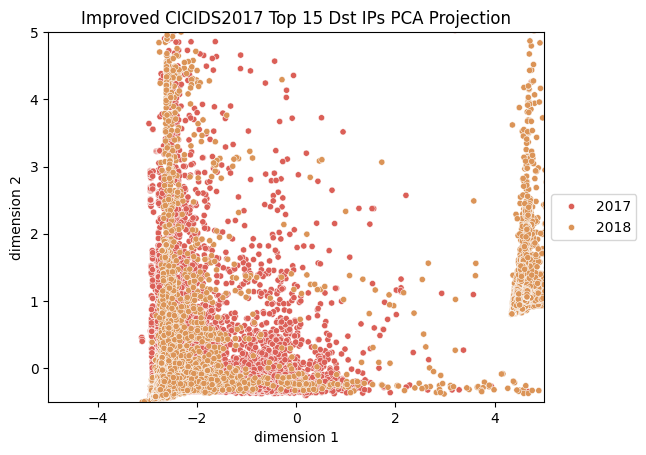

<Figure size 5000x2000 with 0 Axes>

In [95]:
# Limit to top 15 Dst IPs
top_n = 15
top_ips = y.value_counts().nlargest(top_n).index
# filtered_df = pca_15_df[pca_15_df['Label'].isin(top_ips)]
filtered_df = pca_15_df

# Then plot
sns.scatterplot(x='dimension 1', y='dimension 2',
                hue=filtered_df.Label,
                palette=sns.color_palette('hls', top_n),
                s=20,
                data=filtered_df).set(title='Improved CICIDS2017 Top 15 Dst IPs PCA Projection')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xlim(-5,5)
plt.ylim(-0.5,5)
plt.figure(figsize=(50,20))
plt.show()

### Kolmogorov–Smirnov (K-S) test

In [96]:
from scipy.stats import ks_2samp

# Separate the two datasets
X_scaled['dataset'] = dataset
df_2017 = X_scaled[X_scaled['dataset'] == 2017]
df_2018 = X_scaled[X_scaled['dataset'] == 2018]

results = []

# Run K-S test for each feature except 'dataset'
for col in X_scaled.columns:
    if col == 'dataset':
        continue
    stat, p_value = ks_2samp(df_2017[col], df_2018[col])
    results.append({
        'feature': col,
        'ks_statistic': stat,
        'p_value': p_value,
        'different_distribution': p_value < 0.05  # True if significant difference
    })

# Convert to DataFrame for better viewing
ks_results = pd.DataFrame(results).sort_values(by='ks_statistic', ascending=False)

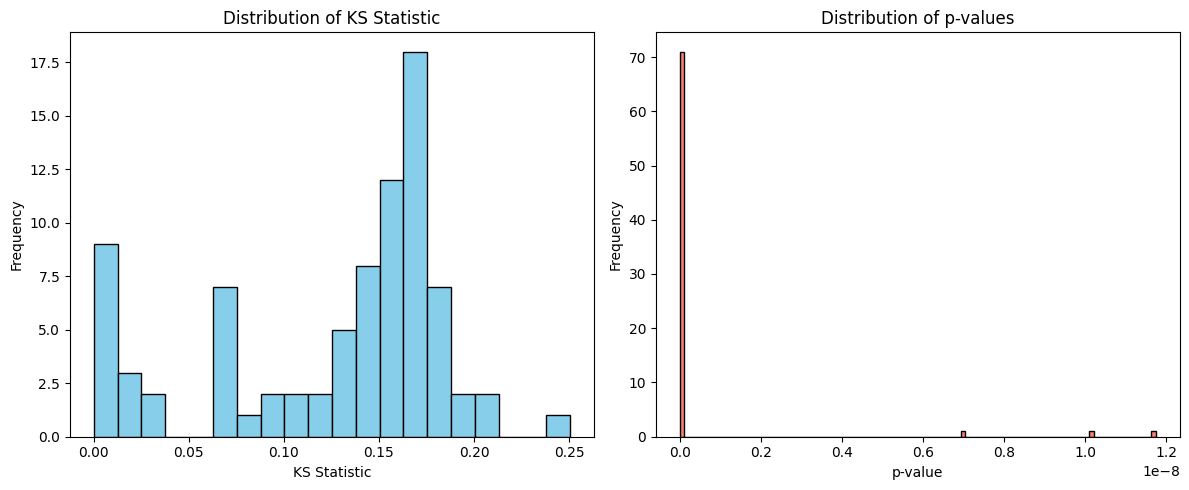

In [98]:
import matplotlib.pyplot as plt

# Extract the KS statistics and p-values
ks_stats = ks_results['ks_statistic']
p_values = ks_results['p_value']
p_values = p_values[(p_values >= 0) & (p_values <= 0.1)]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# KS Statistic histogram
axes[0].hist(ks_stats, bins=20, color='skyblue', edgecolor='black')
axes[0].set_title('Distribution of KS Statistic')
axes[0].set_xlabel('KS Statistic')
axes[0].set_ylabel('Frequency')

# p-value histogram

axes[1].hist(p_values, bins=100, color='salmon', edgecolor='black')
axes[1].set_title('Distribution of p-values')
axes[1].set_xlabel('p-value')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


# 2D-TSNE visualization

In [93]:
subsample_improved_df.columns

Index(['Dst IP', 'Protocol', 'Flow Duration', 'Total Fwd Packet',
       'Total Bwd packets', 'Total Length of Fwd Packet',
       'Total Length of Bwd Packet', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd RST Flags', 'Bwd RST Flags',
       'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s',
       'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max',
       'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance',
       'F

In [ ]:
%%time
X = subsample_improved_df.drop(['Dst IP', 'dataset'], axis = 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns = X.columns)
y = subsample_improved_df['Dst IP']
dataset = subsample_improved_df['dataset']


tsne = TSNE(n_components = 2, n_jobs = -1, verbose = 0, random_state = 0)
z = tsne.fit_transform(X) 

tsne_15_df = pd.DataFrame()
tsne_15_df['Label'] = dataset
tsne_15_df['dimension 1'] = z[:, 0]
tsne_15_df['dimension 2'] = z[:, 1]

sns.scatterplot(x = 'dimension 1', y = 'dimension 2', 
                hue = tsne_15_df.Label,
                palette = sns.color_palette('hls', len(tsne_15_df.Label.value_counts())),
                data = tsne_15_df).set(title = 'CICIDS2017 15 Classes T-SNE Projection')
plt.legend(loc = 'center left', bbox_to_anchor = (1, 0.5)) 
plt.show()

tsne_2_df = pd.DataFrame()
tsne_2_df['Label'] = y
tsne_2_df.loc[tsne_2_df.Label != 'BENIGN', 'Label'] = 'ATTACK'
tsne_2_df['dimension 1'] = z[:, 0]
tsne_2_df['dimension 2'] = z[:, 1]

sns.scatterplot(x = 'dimension 1', y = 'dimension 2', 
                hue = tsne_2_df.Label,
                palette = sns.color_palette('hls', 2),
                data = tsne_2_df).set(title = 'CICIDS2017 Binary Classes T-SNE Projection') 
plt.legend(loc = 'center left', bbox_to_anchor = (1, 0.5)) 
plt.show()

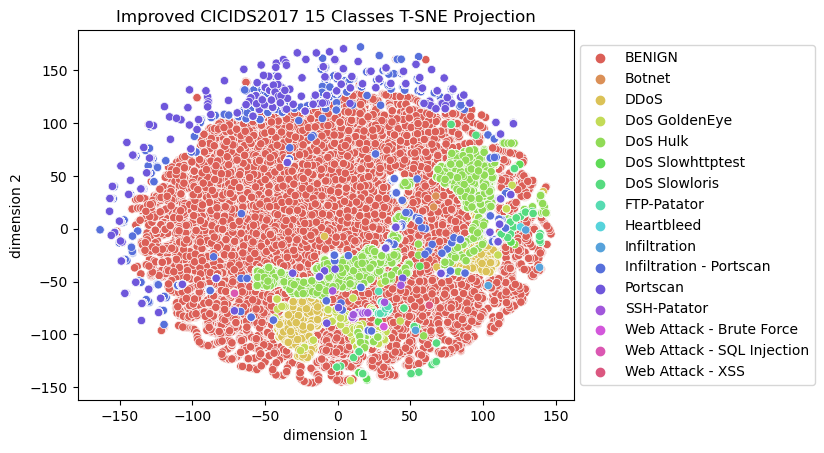

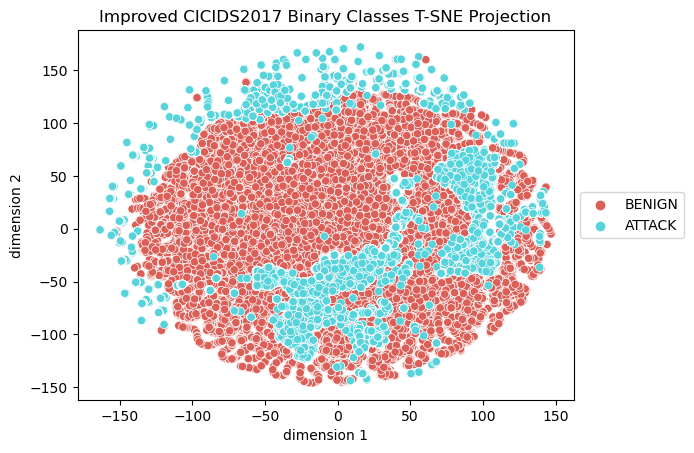

CPU times: user 1h 52min 24s, sys: 1min 41s, total: 1h 54min 6s
Wall time: 37min 41s


In [13]:
%%time
X = subsample_improved_df.drop(['Label'], axis = 1)
y = subsample_improved_df['Label']

tsne = TSNE(n_components = 2, n_jobs = -1, verbose = 0, random_state = 0)
z = tsne.fit_transform(X) 

tsne_15_df = pd.DataFrame()
tsne_15_df['Label'] = y
tsne_15_df['dimension 1'] = z[:, 0]
tsne_15_df['dimension 2'] = z[:, 1]

sns.scatterplot(x = 'dimension 1', y = 'dimension 2', 
                hue = tsne_15_df.Label,
                palette = sns.color_palette('hls', len(tsne_15_df.Label.value_counts())),
                data = tsne_15_df).set(title = 'Improved CICIDS2017 15 Classes T-SNE Projection')
plt.legend(loc = 'center left', bbox_to_anchor = (1, 0.5)) 
plt.show()

tsne_2_df = pd.DataFrame()
tsne_2_df['Label'] = y
tsne_2_df.loc[tsne_2_df.Label != 'BENIGN', 'Label'] = 'ATTACK'
tsne_2_df['dimension 1'] = z[:, 0]
tsne_2_df['dimension 2'] = z[:, 1]

sns.scatterplot(x = 'dimension 1', y = 'dimension 2', 
                hue = tsne_2_df.Label,
                palette = sns.color_palette('hls', 2),
                data = tsne_2_df).set(title = 'Improved CICIDS2017 Binary Classes T-SNE Projection') 
plt.legend(loc = 'center left', bbox_to_anchor = (1, 0.5)) 
plt.show()

# Train, validation, and test split [6](#sixth)

In [14]:
all_malicious = improved_df[improved_df.Label != 'BENIGN']
all_benign = improved_df[improved_df.Label == 'BENIGN']
benign_1M = all_benign.sample(n = 1000000, random_state = 0)

train_size = 500000
test_size = 500000
validation_perc = 0.15

# benign trainin and testing
Y = benign_1M['Label'].map(lambda x: 1 if (x == 'BENIGN') else -1)
labels = benign_1M['Label']

X_train, X_test, y_train, y_test = train_test_split(benign_1M.drop(columns = ['Label']),
                                                    Y,
                                                    train_size = train_size, 
                                                    test_size = test_size, 
                                                    shuffle = True, 
                                                    stratify = Y, 
                                                    random_state = 0)
train_labels, test_labels = labels.loc[y_train.index], labels.loc[y_test.index]

# validation and testing
X_mal = all_malicious.drop(columns = ['Label'])
y_mal = all_malicious['Label'].map(lambda x: 1 if (x == 'Benign') else -1)
labels_mal = all_malicious['Label']

X_test = pd.concat([X_test, X_mal])
y_test = pd.concat([y_test, y_mal])
test_labels = pd.concat([test_labels, labels_mal])

X_val, X_t, y_val, y_t, label_val, label_t = train_test_split(X_test, 
                                                              y_test, 
                                                              test_labels, 
                                                              train_size = validation_perc, 
                                                              random_state = 0, 
                                                              stratify = test_labels, 
                                                              shuffle = True)

print("***** Train Data *****")
print(train_labels.value_counts())
print("***** Validation Data *****")
print(label_val.value_counts())
print("***** Test Data *****")
print(label_t.value_counts())

***** Train Data *****
BENIGN    500000
Name: Label, dtype: int64
***** Validation Data *****
BENIGN                        75000
Portscan                      23860
DoS Hulk                      23770
DDoS                          14271
Infiltration - Portscan       10765
DoS GoldenEye                  1135
FTP-Patator                     596
DoS Slowloris                   579
SSH-Patator                     444
DoS Slowhttptest                261
Botnet                          110
Web Attack - Brute Force         11
Infiltration                      5
Web Attack - XSS                  3
Heartbleed                        2
Web Attack - SQL Injection        2
Name: Label, dtype: int64
***** Test Data *****
BENIGN                        425000
Portscan                      135206
DoS Hulk                      134698
DDoS                           80873
Infiltration - Portscan        61002
DoS GoldenEye                   6432
FTP-Patator                     3376
DoS Slowloris          

# Anomaly score and result evaluation [6](#sixth)

In [15]:
def anomaly_scores(original, transformed):
    sse = np.sum((original - transformed) ** 2, axis = 1) # sum of squared errors
    return sse

def evaluate_results(y_true, score):
    precision, recall, threshold = precision_recall_curve(y_true, score, pos_label = -1)
    au_precision_recall = auc(recall, precision)
    results = pd.DataFrame({'precision': precision, 'recall': recall})
    results['f1'] = 2 * precision * recall / (precision + recall)
    max_index = results['f1'].idxmax()
    best = results.loc[results['f1'].idxmax()]
    best['threshold'] = threshold[max_index]
    best['au_precision_recall'] = au_precision_recall
    fpr, tpr, thresholds = roc_curve(y_true, score, pos_label = -1)
    best['auroc'] = auc(fpr, tpr)
    return best

def evaluate_predictions(y_true, y_pred):
    results = {}
    results['precision'] = precision_score(y_true, y_pred, pos_label = -1, zero_division = 0)
    results['recall'] = recall_score(y_true, y_pred, pos_label = -1, zero_division = 0)
    results['f1'] = f1_score(y_true, y_pred, pos_label = -1, zero_division = 0)
    return results

def evaluate_test_data(y_true, score, threshold):
    y_pred = np.array([1 if score < threshold else -1 for score in score])
    results = evaluate_predictions(y_true, y_pred)
    precision, recall, threshold = precision_recall_curve(y_true, score, pos_label = -1)
    results['au_precision_recall'] = auc(recall, precision)
    fpr, tpr, thresholds = roc_curve(y_true, score, pos_label = -1)
    results['auroc'] = auc(fpr, tpr)
    return results

def pca_classifier(scaler, pca, threshold):
    def clf(X):
        x = scaler.transform(X)
        X_pca = pca.transform(x)
        X_pca_inv = pca.inverse_transform(X_pca)
        score = anomaly_scores(x, X_pca_inv)
        return np.array([1 if score < threshold else -1 for score in score])
    return clf

# PCA intrusion detection [5](#fifth), [6](#sixth)

## Preprocess with scalar [6](#sixth)

## Hyper-parameter tuning [6](#sixth)

In [16]:
%%time

import tqdm

input_dim = X_train.shape[1]

params = {
    'scalers': [StandardScaler(), 
                RobustScaler(quantile_range = (25, 75)), 
                QuantileTransformer(output_distribution = 'normal'), 
                MinMaxScaler(feature_range=(0, 1), copy = True)],
    'n_components': list(range(input_dim)),
}

best_scaler = None
best_pca = None
best_score = None
index = 0
results = []

for (scaler, n_components) in tqdm.tqdm(list(product(params['scalers'], params['n_components']))):
    # print('Scalar', scaler)
    x_train = scaler.fit_transform(X_train)
    x_val = scaler.transform(X_val)
    
    # print('Training number of components', n_components, 'PCA', end = '')
    n_components = 64
    pca = PCA(n_components = n_components, 
                copy = True, 
                whiten = False, 
                svd_solver = 'auto', 
                tol = 0.0, 
                iterated_power = 'auto', 
                random_state = 0)
    pca.fit(x_train)
    X_val_pca = pca.transform(x_val)
    X_val_pca_inv = pca.inverse_transform(X_val_pca)
    val_score = anomaly_scores(x_val, X_val_pca_inv)
    val_metrics = evaluate_results(y_val, val_score)
    val_metrics['n_components'] = n_components
    val_metrics['scaler'] = scaler
    val_metrics['index'] = index
    results.append(val_metrics)
    # print('validation auroc', val_metrics['auroc'])
    
    index += 1
    
    if best_score is None or val_metrics['auroc'] > best_score['auroc']:
        best_scaler = scaler
        best_pca = pca
        best_score = val_metrics


100%|██████████| 328/328 [1:25:08<00:00, 15.57s/it]

CPU times: user 2h 49min 5s, sys: 47min 5s, total: 3h 36min 11s
Wall time: 1h 25min 8s


In [17]:
print('Best scaler', best_score['scaler'], 'Best number of components', best_score['n_components'])
x_t = best_scaler.transform(X_t)
X_t_pca = best_pca.transform(x_t)
X_t_pca_inv = best_pca.inverse_transform(X_t_pca)
test_score = anomaly_scores(x_t, X_t_pca_inv)

print('Test performance on all attacks')
pprint(evaluate_test_data(y_t, test_score, best_score.threshold))

Best scaler QuantileTransformer(output_distribution='normal') Best number of components 64.0
Test performance on all attacks
{'au_precision_recall': 0.9092582664921672,
 'auroc': 0.9216302073077675,
 'f1': 0.853774877284716,
 'precision': 0.809609469233755,
 'recall': 0.9030368909982612}


In [18]:
df = pd.DataFrame({'label_t': label_t, 'y_test': y_t, 'test_score': test_score})
test_df = df[(df.label_t == 'DoS Slowloris') | (df.label_t == 'DoS Slowhttptest') | (df.label_t == 'BENIGN')]

print('Test performance on DoS Slowloris and Slowhttptest')
pprint(evaluate_test_data(test_df.y_test.tolist(), test_df.test_score.tolist(), best_score.threshold))

Test performance on DoS Slowloris and Slowhttptest
{'au_precision_recall': 0.1842091475787321,
 'auroc': 0.9668418906591844,
 'f1': 0.09437501861097601,
 'precision': 0.04952702421135975,
 'recall': 0.9989493591090566}


In [19]:
for label in [s for s in improved_df['Label'].unique() if s != 'BENIGN']:
    test_df = df[(df.label_t == label) | (df.label_t == 'BENIGN')]
    
    print('Test performance on', label)
    pprint(evaluate_test_data(test_df.y_test.tolist(), test_df.test_score.tolist(), best_score.threshold))

Test performance on FTP-Patator
{'au_precision_recall': 0.023744121871048768,
 'auroc': 0.841853185809869,
 'f1': 0.06878954888752806,
 'precision': 0.03562217242399898,
 'recall': 0.9982227488151659}
Test performance on SSH-Patator
{'au_precision_recall': 0.007302431663593303,
 'auroc': 0.60849993876931,
 'f1': 0.000575828019364883,
 'precision': 0.0002958547462771611,
 'recall': 0.010727056019070322}
Test performance on DoS Slowloris
{'au_precision_recall': 0.1623154495409992,
 'auroc': 0.9729041334289814,
 'f1': 0.06704024869109948,
 'precision': 0.03468342644320298,
 'recall': 0.999390243902439}
Test performance on DoS Slowhttptest
{'au_precision_recall': 0.04441064695310847,
 'auroc': 0.9533975659229209,
 'f1': 0.031341239422862543,
 'precision': 0.015920612663143135,
 'recall': 0.9979716024340771}
Test performance on DoS Hulk
{'au_precision_recall': 0.7609364448341966,
 'auroc': 0.9245216065743584,
 'f1': 0.7147619318505034,
 'precision': 0.5793380732379819,
 'recall': 0.93281266

# SHAP explainability

Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
Permutation explainer: 8547it [1:51:14,  1.28it/s]


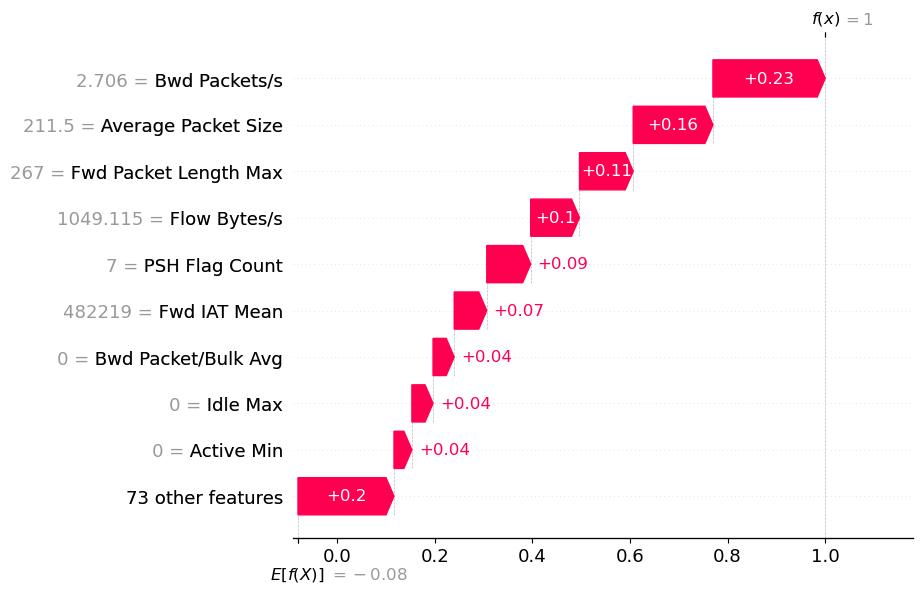

In [20]:
import shap

subsample_X_t = pd.DataFrame.sample(X_t, frac = 0.01).reset_index(drop = True)

# explain the model's predictions using SHAP
explainer = shap.Explainer(pca_classifier(best_scaler, best_pca, best_score.threshold), 
                           masker = shap.maskers.Independent(data = subsample_X_t))
shap_values = explainer(subsample_X_t)

# visualize the first prediction's explanation
shap.plots.waterfall(shap_values[0])

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


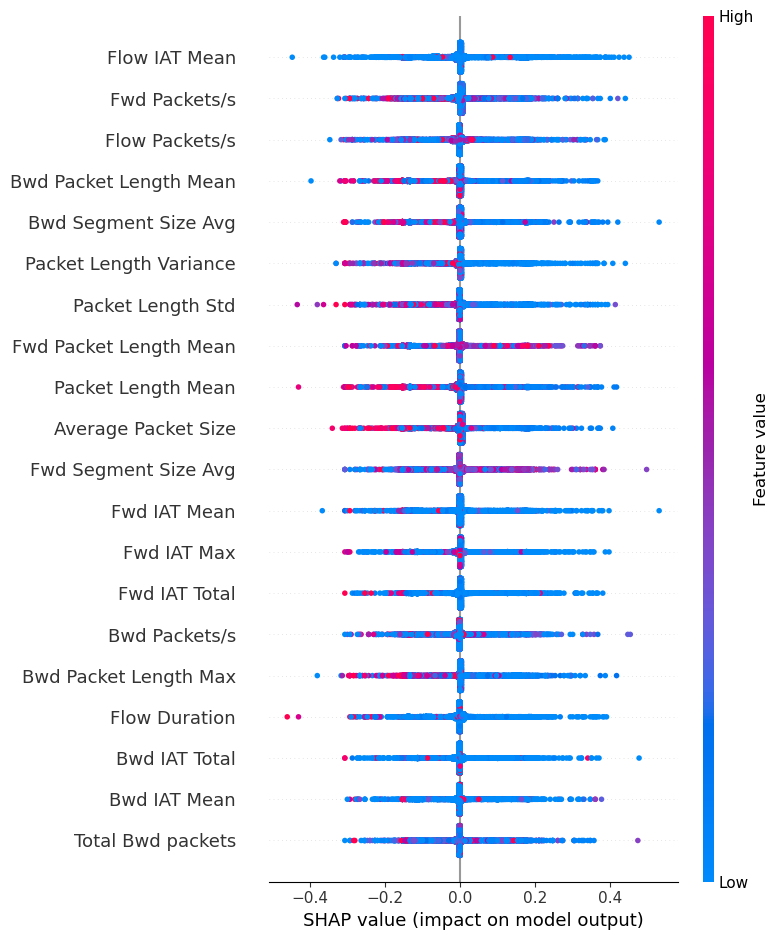

In [21]:
shap.summary_plot(shap_values, subsample_X_t)

The figure layout has changed to tight


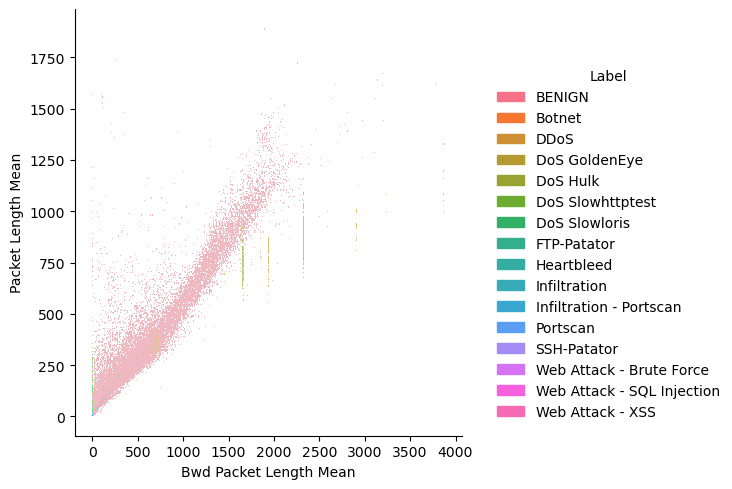

In [22]:
sns.displot(
    data = subsample_improved_df,
    x = 'Bwd Packet Length Mean', y = 'Packet Length Mean', hue = 'Label',
)
# Bwd Segment Size Avg, Subflow Bwd Bytes, Protocol, Fwd Packet Length Mean

The figure layout has changed to tight


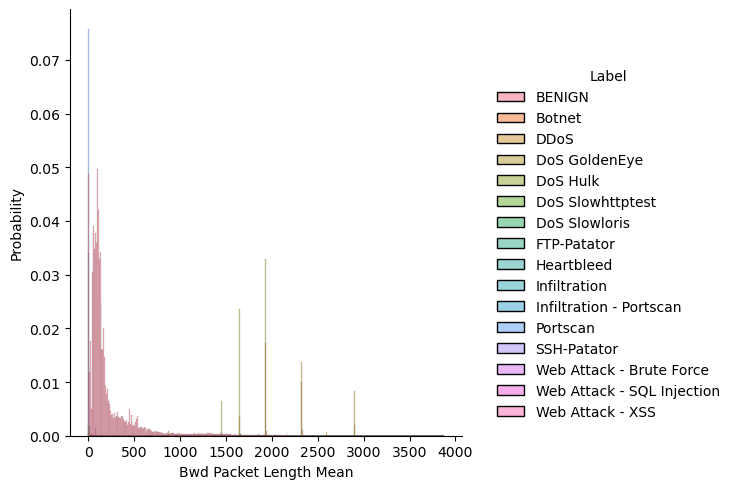

In [23]:
sns.displot(subsample_improved_df, x = 'Bwd Packet Length Mean', hue = 'Label', stat = 'probability')#, kind = 'kde')

Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
The figure layout has changed to tight


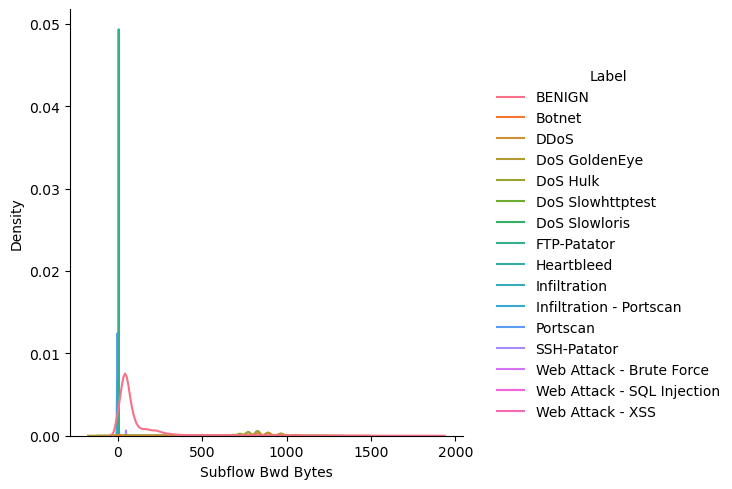

In [24]:
sns.displot(subsample_improved_df, x = 'Subflow Bwd Bytes', hue = 'Label', kind = 'kde')

Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
The figure layout has changed to tight


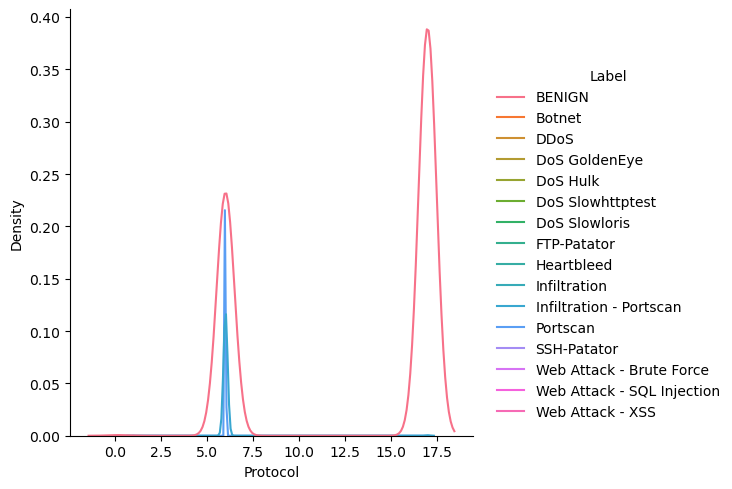

In [25]:
sns.displot(subsample_improved_df, x = 'Protocol', hue = 'Label', kind = 'kde')

In [26]:
improved_df.to_csv('cleaned_improved_cicids2017.csv', encoding = 'utf-8', index = False)

# Reference
1. <a id='first'></a>[Liu, Lisa, et al. "Error prevalence in nids datasets: A case study on cic-ids-2017 and cse-cic-ids-2018." 2022 IEEE Conference on Communications and Network Security (CNS). IEEE, 2022.](https://ieeexplore.ieee.org/abstract/document/9947235)
2. <a id='second'></a>[Lanvin, Maxime, et al. "Errors in the CICIDS2017 dataset and the significant differences in detection performances it makes." International Conference on Risks and Security of Internet and Systems. Cham: Springer Nature Switzerland, 2022.](https://link.springer.com/chapter/10.1007/978-3-031-31108-6_2)
3. <a id='third'></a>[Improved CIC-IDS 2017 Documentation](https://intrusion-detection.distrinet-research.be/CNS2022/CICIDS2017.html)
4. <a id='fourth'></a>[Error Prevalence in NIDS datasets: A Case Study on CIC-IDS-2017 and CSE-CIC-IDS-2018 (G. Engelen)](https://www.youtube.com/watch?v=sJvZKhw3lYo)
5. <a id='fifth'></a>Verkerken, Miel, et al. "Towards model generalization for intrusion detection: Unsupervised machine learning techniques." Journal of Network and Systems Management 30 (2022): 1-25.
6. <a id='sixth'></a>[CIC-IDS-2018](https://gitlab.ilabt.imec.be/mverkerk/cic-ids-2018)
7. Yang, Li, et al. "LCCDE: A decision-based ensemble framework for intrusion detection in the internet of vehicles." GLOBECOM 2022-2022 IEEE Global Communications Conference. IEEE, 2022.
8. [TSNE Visualization Example in Python](https://www.datatechnotes.com/2020/11/tsne-visualization-example-in-python.html)
9. [Multicore t-SNE](https://github.com/DmitryUlyanov/Multicore-TSNE)
10. [sklearn.manifold.TSNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html)
11. [What do maskers really do in SHAP package and fit them to train or test?](https://stackoverflow.com/questions/66560839/what-do-maskers-really-do-in-shap-package-and-fit-them-to-train-or-test)
12. [Python Statistics Fundamentals: How to Describe Your Data](https://realpython.com/python-statistics/)